# Hw4: Neural Retrieval and Re-Ranking

**Datasets:**
- **WikIR (en1k)** — https://github.com/getalp/wikIR
- **MIRAGE** — https://github.com/nlpai-lab/MIRAGE

**Tasks:**
1. Ranking
2. Re-ranking BM25 results
3. Mixture model: alpha * BM25 + (1-alpha) * cosine_similarity

In [1]:
!pip install sentence-transformers rank_bm25 ir-datasets ir-measures tqdm pandas numpy scikit-learn torch transformers

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 22.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 27.0 MB/s eta 0:00:00
  Created wheel for warc3-wet-clueweb09: filename=warc3_wet_clueweb09-0.2.5-py3-none-any.whl size=18919 sha256=8db2b15ff4ef7403c79ebf826863fc7d8096dfccb8930428caa4861402f7a238
  Stored in directory: /root/.cache/pip/wheels/f6/85/c2/9f0f621def52a1d5db7d29984f81e45f9fb6dfeb1a4eb6e31c
  Created wheel for cbor: filename=cbor-1.0.0-cp312-cp312-linux_x86_64.whl size=55023 sha256=837af9a1ff3ab7445beaa8c5402fad0c072f63c6c09281ae6ecdd62734d4d

### 1.1 WikIR (en1k)

In [2]:
import ir_datasets

def load_wikir_irdatasets(train_id='wikir/en1k/training', test_id='wikir/en1k/test'):
    train_ds = ir_datasets.load(train_id)
    test_ds  = ir_datasets.load(test_id)

    print('Loading corpus...')
    corpus = {doc.doc_id: doc.text for doc in train_ds.docs_iter()}
    print(f'Corpus: {len(corpus)} documents')

    train_queries = {q.query_id: q.text for q in train_ds.queries_iter()}
    test_queries  = {q.query_id: q.text for q in test_ds.queries_iter()}
    print(f'Train queries: {len(train_queries)}, Test queries: {len(test_queries)}')

    def load_qrels(ds):
        qrels = {}
        for qrel in ds.qrels_iter():
            qrels.setdefault(qrel.query_id, {})[qrel.doc_id] = qrel.relevance
        return qrels

    train_qrels = load_qrels(train_ds)
    test_qrels  = load_qrels(test_ds)
    print(f'Train qrels: {len(train_qrels)} queries, Test qrels: {len(test_qrels)} queries')

    return corpus, train_queries, test_queries, train_qrels, test_qrels


wikir_corpus, wikir_train_q, wikir_test_q, wikir_train_qrels, wikir_test_qrels = load_wikir_irdatasets()

# Sanity check
print('\nSample query:', list(wikir_test_q.items())[:2])
print('Sample doc:  ', list(wikir_corpus.items())[:1])
all_rels = {r for qrel in wikir_test_qrels.values() for r in qrel.values()}
print('Relevance values:', all_rels, '(1=linked article, 2=same article)')

Loading corpus...


[INFO] If you have a local copy of https://zenodo.org/record/3565761/files/wikIR1k.zip, you can symlink it here to avoid downloading it again: /root/.ir_datasets/downloads/554299bca984640cb283d6ba55753608
[INFO] [starting] https://zenodo.org/record/3565761/files/wikIR1k.zip
[INFO] [finished] https://zenodo.org/record/3565761/files/wikIR1k.zip: [01:08] [165MB] [2.40MB/s]


Corpus: 369721 documents
Train queries: 1444, Test queries: 100
Train qrels: 1444 queries, Test qrels: 100 queries

Sample query: [('158491', 'southern methodist university'), ('5728', 'halakha')]
Sample doc:   [('1781133', 'it was used in landing craft during world war ii and is used today in private boats and training facilities the 6 71 is an inline six cylinder diesel engine the 71 refers to the displacement in cubic inches of each cylinder the firing order of the engine is 1 5 3 6 2 4 the engine s compression ratio is 18 7 1 with a 4 250 inch bore and a 5 00 inch stroke the engine weighs and is 54 inches long 29 inches wide and 41 inches tall at 2 100 revolutions per minute the engine is capable of producing 230 horse power 172 kilowatts v type versions of the 71 series were developed in 1957 the 6 71 is a two stroke engine as the engine will not naturally aspirate air is provided via a roots type blower however on the 6 71t models a turbocharger and a supercharger are utilized fu

Возьмем срез данных, иначе получаются слишком долгие вычисления далее

In [27]:
import random

def subsample_corpus(corpus, qrels, max_docs=50000, seed=42):
    """Все релевантные документы + случайные до max_docs."""
    random.seed(seed)
    relevant_ids = {did for qrel in qrels.values() for did in qrel}
    other_ids = [did for did in corpus if did not in relevant_ids]
    random.shuffle(other_ids)
    keep = relevant_ids | set(other_ids[:max_docs - len(relevant_ids)])
    return {did: corpus[did] for did in keep}

wikir_corpus_exp = subsample_corpus(wikir_corpus, wikir_test_qrels, max_docs=50000)

wikir_corpus_train_exp = subsample_corpus(wikir_corpus, wikir_train_qrels, max_docs=50000)

print(f'Full corpus:       {len(wikir_corpus)}')
print(f'Test experiment:   {len(wikir_corpus_exp)}')
print(f'Train experiment:  {len(wikir_corpus_train_exp)}')

Full corpus:       369721
Test experiment:   50000
Train experiment:  50000


### 1.2 MIRAGE


In [3]:
from datasets import load_dataset
mirage_ds = load_dataset('nlpai-lab/MIRAGE')

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/35.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7560 [00:00<?, ? examples/s]

In [9]:
def build_mirage_structures(ds):
    data = ds['train']
    corpus, queries, qrels = {}, {}, {}

    for row in data:
        qid = str(row['query_id'])
        queries[qid] = row['query']

        pool_ids        = row['doc_pool']['mapped_id']
        pool_chunks     = row['doc_pool']['doc_chunk']
        pool_supports   = row['doc_pool']['support']

        qrels[qid] = {}
        for i, (mid, chunk, support) in enumerate(zip(pool_ids, pool_chunks, pool_supports)):
            doc_id = f"{mid}__{i}"
            corpus[doc_id] = chunk
            if mid == qid and support == 1:
                qrels[qid][doc_id] = 1

    print(f'MIRAGE: {len(queries)} queries, {len(corpus)} documents')
    return corpus, queries, qrels


mirage_corpus, mirage_test_q, mirage_test_qrels = build_mirage_structures(mirage_ds)

MIRAGE: 7560 queries, 37800 documents


## 2. Evaluation Metrics

In [5]:
import numpy as np
from collections import defaultdict

def precision_at_k(ranked_docs, qrels, k):
    top_k = ranked_docs[:k]
    hits = sum(1 for d in top_k if qrels.get(d, 0) > 0)
    return hits / k

def average_precision_at_k(ranked_docs, qrels, k):
    top_k = ranked_docs[:k]
    hits = 0
    sum_prec = 0.0
    for i, doc in enumerate(top_k, 1):
        if qrels.get(doc, 0) > 0:
            hits += 1
            sum_prec += hits / i
    if hits == 0:
        return 0.0
    n_rel = sum(1 for v in qrels.values() if v > 0)
    return sum_prec / min(k, n_rel) if n_rel > 0 else 0.0

def ndcg_at_k(ranked_docs, qrels, k):
    top_k = ranked_docs[:k]
    dcg = sum(
        qrels.get(doc, 0) / np.log2(i + 1)
        for i, doc in enumerate(top_k, 1)
    )
    ideal_rels = sorted(qrels.values(), reverse=True)[:k]
    idcg = sum(
        rel / np.log2(i + 1)
        for i, rel in enumerate(ideal_rels, 1)
    )
    return dcg / idcg if idcg > 0 else 0.0


def evaluate_run(run, all_qrels, ks=(1, 10, 20)):
    metrics = defaultdict(list)
    for qid, ranked in run.items():
        qrel = all_qrels.get(qid, {})
        if not qrel:
            continue
        ranked_docs = [doc_id for doc_id, _ in ranked]
        for k in ks:
            metrics[f'P@{k}'].append(precision_at_k(ranked_docs, qrel, k))
        metrics['MAP@20'].append(average_precision_at_k(ranked_docs, qrel, 20))
        metrics['nDCG@20'].append(ndcg_at_k(ranked_docs, qrel, 20))
    
    result = {m: float(np.mean(v)) for m, v in metrics.items()}
    return result


def print_metrics(name, metrics):
    print(f'\n=== {name} ===')
    for m, v in sorted(metrics.items()):
        print(f'  {m}: {v:.4f}')

## 3. BM25 Baseline

BM25 бэйзлайн (для сравнения результатов neural ranking, также далее понадобится для re-ranking-a)

In [34]:
from rank_bm25 import BM25Okapi
import re
from tqdm.auto import tqdm
import numpy as np 

def tokenize(text):
    return re.findall(r'\w+', text.lower())

def build_bm25_index(corpus):
    doc_ids = list(corpus.keys())
    tokenized = [tokenize(corpus[did]) for did in tqdm(doc_ids, desc='BM25 tokenize')]
    bm25 = BM25Okapi(tokenized)
    return bm25, doc_ids

def bm25_search(bm25, doc_ids, query, top_k=100):
    import numpy as np
    scores = bm25.get_scores(tokenize(query))
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [(doc_ids[i], float(scores[i])) for i in top_indices]

def run_bm25(corpus, queries, top_k=100):
    bm25, doc_ids = build_bm25_index(corpus)
    run = {qid: bm25_search(bm25, doc_ids, qtext, top_k=top_k)
           for qid, qtext in tqdm(queries.items(), desc='BM25 search')}
    return run, bm25, doc_ids

In [28]:
# WikIR BM25
print('Building BM25 index for WikIR...')
wikir_bm25_run, wikir_bm25_obj, wikir_doc_ids = run_bm25(wikir_corpus_exp, wikir_test_q, top_k=100)

wikir_bm25_train_obj, wikir_doc_ids_train = build_bm25_index(wikir_corpus_train_exp)
wikir_bm25_train_run = {
    qid: bm25_search(wikir_bm25_train_obj, wikir_doc_ids_train, qtext, top_k=100)
    for qid, qtext in tqdm(wikir_train_q.items(), desc='BM25 train')
}

wikir_bm25_metrics = evaluate_run(wikir_bm25_run, wikir_test_qrels)
print_metrics('WikIR BM25 (test)', wikir_bm25_metrics)

Building BM25 index for WikIR...


BM25 tokenize:   0%|          | 0/50000 [00:00<?, ?it/s]

BM25 search:   0%|          | 0/100 [00:00<?, ?it/s]

BM25 tokenize:   0%|          | 0/50000 [00:00<?, ?it/s]

BM25 train:   0%|          | 0/1444 [00:00<?, ?it/s]


=== WikIR BM25 (test) ===
  MAP@20: 0.3497
  P@1: 0.7800
  P@10: 0.3780
  P@20: 0.2635
  nDCG@20: 0.5566


In [29]:
# MIRAGE BM25
print('Building BM25 index for MIRAGE...')
mirage_bm25_run, mirage_bm25_obj, mirage_doc_ids = run_bm25(mirage_corpus, mirage_test_q, top_k=100)

mirage_bm25_metrics = evaluate_run(mirage_bm25_run, mirage_test_qrels)
print_metrics('MIRAGE BM25 (test)', mirage_bm25_metrics)

Building BM25 index for MIRAGE...


BM25 tokenize:   0%|          | 0/37800 [00:00<?, ?it/s]

BM25 search:   0%|          | 0/7560 [00:00<?, ?it/s]


=== MIRAGE BM25 (test) ===
  MAP@20: 0.5630
  P@1: 0.4877
  P@10: 0.0884
  P@20: 0.0472
  nDCG@20: 0.6237


## Task 1: Ranking with SentenceTransformers (Bi-Encoders)

Берем две модели: `msmarco-bert-base-dot-v5` и `multi-qa-MiniLM-L6-cos-v1`

In [31]:
from sentence_transformers import SentenceTransformer, util
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [60]:
corpus_embeddings_cache = {}

def biencoder_retrieve(model_name, corpus, queries, batch_size=128, top_k=100, corpus_cache_key=None):
    model = SentenceTransformer(model_name, device=device)

    cache_key = (model_name, corpus_cache_key)
    if cache_key in corpus_embeddings_cache:
        print('Using cached corpus embeddings...')
        doc_ids, doc_embeddings = corpus_embeddings_cache[cache_key]
    else:
        doc_ids = list(corpus.keys())
        doc_texts = [corpus[did] for did in doc_ids]
        print(f'Encoding {len(doc_texts)} documents...')
        doc_embeddings = model.encode(
            doc_texts, batch_size=batch_size,
            show_progress_bar=True, convert_to_tensor=True,
            normalize_embeddings=True
        )
        if corpus_cache_key is not None:
            corpus_embeddings_cache[cache_key] = (doc_ids, doc_embeddings)

    query_ids = list(queries.keys())
    query_texts = [queries[qid] for qid in query_ids]
    print(f'Encoding {len(query_texts)} queries...')
    query_embeddings = model.encode(
        query_texts, batch_size=batch_size,
        show_progress_bar=True, convert_to_tensor=True,
        normalize_embeddings=True
    )

    results = util.semantic_search(
        query_embeddings, doc_embeddings,
        top_k=min(top_k, len(doc_ids)),
        score_function=util.cos_sim  # <-- не строка, а функция
    )

    run = {qid: [(doc_ids[h['corpus_id']], float(h['score'])) for h in hits]
           for qid, hits in zip(query_ids, results)}

    return run, model, doc_embeddings, doc_ids

In [43]:
TOP_K = 100
results_table = {}
stored = {}

In [58]:
import gc

def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    print(f'GPU memory free: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB')

In [ ]:
clear_gpu()
model_name = 'multi-qa-MiniLM-L6-cos-v1'
print(f'Model: {model_name}')

wikir_run, model_obj, wikir_doc_embs, _ = biencoder_retrieve(
    model_name, wikir_corpus_exp, wikir_test_q,
    top_k=TOP_K, corpus_cache_key=f'wikir_{model_name}'
)
wikir_m = evaluate_run(wikir_run, wikir_test_qrels)
print_metrics(f'{model_name} / WikIR test', wikir_m)

mirage_run, _, mirage_doc_embs, _ = biencoder_retrieve(
    model_name, mirage_corpus, mirage_test_q,
    top_k=TOP_K, corpus_cache_key=f'mirage_{model_name}'
)
mirage_m = evaluate_run(mirage_run, mirage_test_qrels)
print_metrics(f'{model_name} / MIRAGE test', mirage_m)

results_table[f'BiEncoder: {model_name}'] = {'WikIR': wikir_m, 'MIRAGE': mirage_m}
stored[model_name] = (wikir_run, mirage_run, None, wikir_doc_embs, mirage_doc_embs)

In [ ]:
clear_gpu()
model_name = 'msmarco-MiniLM-L6-cos-v5'
print(f'Model: {model_name}')

wikir_run, model_obj, wikir_doc_embs, _ = biencoder_retrieve(
    model_name, wikir_corpus_exp, wikir_test_q,
    top_k=TOP_K, corpus_cache_key=f'wikir_{model_name}'
)
wikir_m = evaluate_run(wikir_run, wikir_test_qrels)
print_metrics(f'{model_name} / WikIR test', wikir_m)

mirage_run, _, mirage_doc_embs, _ = biencoder_retrieve(
    model_name, mirage_corpus, mirage_test_q,
    top_k=TOP_K, corpus_cache_key=f'mirage_{model_name}'
)
mirage_m = evaluate_run(mirage_run, mirage_test_qrels)
print_metrics(f'{model_name} / MIRAGE test', mirage_m)

results_table[f'BiEncoder: {model_name}'] = {'WikIR': wikir_m, 'MIRAGE': mirage_m}
stored[model_name] = (wikir_run, mirage_run, None, wikir_doc_embs, mirage_doc_embs)

In [71]:
import pandas as pd

METRICS_ORDER = ['P@1', 'P@10', 'P@20', 'MAP@20', 'nDCG@20']

def build_summary_df(results_table):
    rows = []
    for system, datasets in results_table.items():
        for dataset, metrics in datasets.items():
            row = {'System': system, 'Dataset': dataset}
            for m in METRICS_ORDER:
                row[m] = round(metrics.get(m, float('nan')), 4)
            rows.append(row)
    
    df = pd.DataFrame(rows)
    df = df.set_index(['System', 'Dataset'])
    return df

df = build_summary_df(results_table)

display(df.style
    .highlight_max(axis=0, color='lightgreen')
    .format('{:.4f}')
    .set_caption('Retrieval Results')
)

## Task 2: Re-Ranking BM25


In [91]:
from sentence_transformers import CrossEncoder

RERANK_K_VALUES = [10, 50, 100]

def rerank_msmarco(ce_model, queries, corpus, bm25_run, rerank_k=100):
    run = {}
    for qid, qtext in tqdm(queries.items(), desc=f'Re-rank k={rerank_k}'):
        top_docs = bm25_run.get(qid, [])[:rerank_k]
        if not top_docs:
            run[qid] = []
            continue
        
        doc_ids = [d for d, _ in top_docs]
        doc_texts = [corpus.get(did, '') for did in doc_ids]
        
        pairs = [[qtext, dtxt] for dtxt in doc_texts]
        ce_scores = ce_model.predict(pairs, show_progress_bar=False)
        
        sorted_results = sorted(
            zip(doc_ids, ce_scores),
            key=lambda x: x[1], reverse=True
        )
        run[qid] = [(did, float(sc)) for did, sc in sorted_results]
    
    return run

In [ ]:
results_table_2 = {}
ce_name = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
ce_model = CrossEncoder(ce_name, device=device)

for k in RERANK_K_VALUES:
    wikir_rerank_run = rerank_msmarco(
        ce_model, wikir_test_q, wikir_corpus_exp, wikir_bm25_run, rerank_k=k
    )
    wikir_m = evaluate_run(wikir_rerank_run, wikir_test_qrels)
    print_metrics(f'WikIR Re-rank k={k}', wikir_m)

    mirage_rerank_run = rerank_msmarco(
        ce_model, mirage_test_q, mirage_corpus, mirage_bm25_run, rerank_k=k
    )
    mirage_m = evaluate_run(mirage_rerank_run, mirage_test_qrels)
    print_metrics(f'MIRAGE Re-rank k={k}', mirage_m)

    results_table_2[f'Rerank({ce_name},k={k})'] = {
            'WikIR': wikir_m,
            'MIRAGE': mirage_m,
        }

In [81]:
def build_rerank_df(results_table, dataset='WikIR'):
    rows = []
    for system, datasets in results_table.items():
        if dataset not in datasets:
            continue
        # Парсим имя модели и k из ключа
        # Формат: 'Rerank(model_name,k=N)'
        inner = system.replace('Rerank(', '').replace(')', '')
        parts = inner.rsplit(',k=', 1)
        model_short = parts[0].split('/')[-1]  # только последняя часть пути
        k = int(parts[1])
        
        row = {'Model': model_short, 'k': k}
        for m in METRICS_ORDER:
            row[m] = round(datasets[dataset].get(m, float('nan')), 4)
        rows.append(row)
    
    df = pd.DataFrame(rows).set_index(['Model', 'k']).sort_index()
    return df

for dataset in ['WikIR', 'MIRAGE']:
    df = build_rerank_df(results_table_2, dataset)
    print(f'\nDataset: {dataset}')
    display(df.style
        .highlight_max(axis=0, color='lightgreen')
        .format('{:.4f}')
    )


Dataset: WikIR



Dataset: MIRAGE


In [94]:
RERANK_K_VALUES = [10, 50, 100]
model_name = 'multi-qa-MiniLM-L6-cos-v1'
model = SentenceTransformer(model_name, device=device)

def rerank_multiqa(model, queries, corpus, bm25_run, rerank_k=100):
    run = {}
    for qid, qtext in tqdm(queries.items(), desc=f'BE re-rank k={rerank_k}'):
        top_docs = bm25_run.get(qid, [])[:rerank_k]
        if not top_docs:
            run[qid] = []
            continue
        doc_ids = [d for d, _ in top_docs]
        doc_texts = [corpus.get(did, '') for did in doc_ids]
        q_emb = model.encode(qtext, convert_to_tensor=True, normalize_embeddings=True)
        d_embs = model.encode(doc_texts, convert_to_tensor=True,
                              normalize_embeddings=True, batch_size=256)
        scores = util.cos_sim(q_emb, d_embs)[0]
        run[qid] = sorted(
            zip(doc_ids, scores.tolist()),
            key=lambda x: x[1], reverse=True
        )
    return run

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
results_table_3 = {}
for k in RERANK_K_VALUES:
    wikir_be_run = rerank_multiqa(
        model, wikir_test_q, wikir_corpus_exp, wikir_bm25_run, rerank_k=k
    )
    wikir_m = evaluate_run(wikir_be_run, wikir_test_qrels)
    print_metrics(f'Rerank({model_name}) WikIR k={k}', wikir_m)

    mirage_be_run = rerank_multiqa(
        model, mirage_test_q, mirage_corpus, mirage_bm25_run, rerank_k=k
    )
    mirage_m = evaluate_run(mirage_be_run, mirage_test_qrels)
    print_metrics(f'Rerank({model_name}) MIRAGE k={k}', mirage_m)

    results_table_3[f'Rerank({model_name},k={k})'] = {'WikIR': wikir_m, 'MIRAGE': mirage_m}

In [104]:
for dataset in ['WikIR', 'MIRAGE']:
    df = build_rerank_df(results_table_3, dataset)
    print(f'\nDataset: {dataset}')
    display(df.style
        .highlight_max(axis=0, color='lightgreen')
        .format('{:.4f}')
    )


Dataset: WikIR



Dataset: MIRAGE


## Task 3: Mixture Model

Формула: **score = alpha * BM25_norm + (1 - alpha) * cosine_similarity**

In [83]:
def minmax_normalize(scores_list):
    if not scores_list:
        return {}
    vals = np.array([s for _, s in scores_list], dtype=float)
    mn, mx = vals.min(), vals.max()
    if mx == mn:
        return {did: 0.5 for did, _ in scores_list}
    normalized = (vals - mn) / (mx - mn)
    return {did: float(n) for (did, _), n in zip(scores_list, normalized)}

In [ ]:
MIXTURE_MODEL = 'multi-qa-MiniLM-L6-cos-v1'

_, _, _, wikir_doc_embs, _ = stored[MIXTURE_MODEL]
mixture_model = SentenceTransformer(MIXTURE_MODEL, device=device)

doc_ids_list = list(wikir_corpus_exp.keys()) 

train_query_ids = list(wikir_train_q.keys())
train_query_texts = [wikir_train_q[qid] for qid in train_query_ids]

train_q_embs = mixture_model.encode(
    train_query_texts, batch_size=1024, show_progress_bar=True,
    convert_to_tensor=True, normalize_embeddings=True
)

train_dense_results = util.semantic_search(
    train_q_embs, wikir_doc_embs, top_k=100,
    score_function=util.cos_sim
)
wikir_train_dense_run = {
    qid: [(doc_ids_list[h['corpus_id']], float(h['score'])) for h in hits]
    for qid, hits in zip(train_query_ids, train_dense_results)
}

Alpha search:   0%|          | 0/21 [00:00<?, ?it/s]


Best alpha = 0.85, MAP@20 = 0.3651


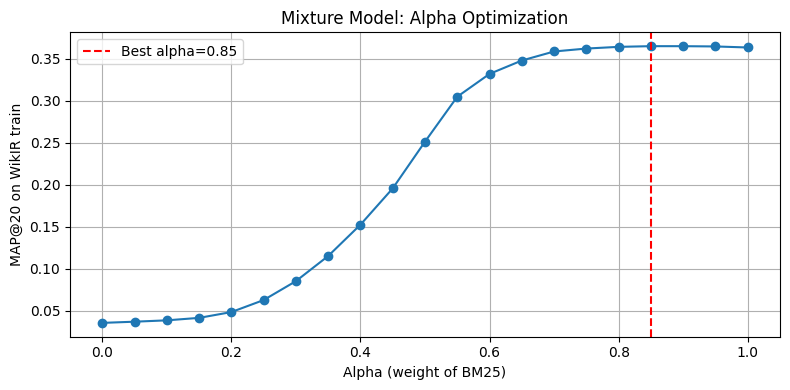

In [86]:
# Grid search
alphas = np.linspace(0.0, 1.0, 21)  # 0.0, 0.05, 0.10, ..., 1.0
alpha_results = []

for alpha in tqdm(alphas, desc='Alpha search'):
    run = mixture_run(wikir_bm25_train_run, wikir_train_dense_run, alpha)
    m = evaluate_run(run, wikir_train_qrels)
    alpha_results.append((alpha, m['MAP@20']))

best_alpha, best_map = max(alpha_results, key=lambda x: x[1])
print(f'\nBest alpha = {best_alpha:.2f}, MAP@20 = {best_map:.4f}')


import matplotlib.pyplot as plt
alphas_list = [a for a, _ in alpha_results]
maps_list = [m for _, m in alpha_results]
plt.figure(figsize=(8, 4))
plt.plot(alphas_list, maps_list, marker='o')
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best alpha={best_alpha:.2f}')
plt.xlabel('Alpha (weight of BM25)')
plt.ylabel('MAP@20 on WikIR train')
plt.title('Mixture Model: Alpha Optimization')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('alpha_optimization.png', dpi=150)
plt.show()

In [88]:
wikir_test_dense_run = stored[MIXTURE_MODEL][0]
mirage_test_dense_run = stored[MIXTURE_MODEL][1]

# WikIR test
wikir_mixture_run = mixture_run(wikir_bm25_run, wikir_test_dense_run, best_alpha)
wikir_mixture_m = evaluate_run(wikir_mixture_run, wikir_test_qrels)
print_metrics(f'WikIR Mixture alpha={best_alpha:.2f}', wikir_mixture_m)

# MIRAGE test
mirage_mixture_run = mixture_run(mirage_bm25_run, mirage_test_dense_run, best_alpha)
mirage_mixture_m = evaluate_run(mirage_mixture_run, mirage_test_qrels)
print_metrics(f'MIRAGE Mixture alpha={best_alpha:.2f}', mirage_mixture_m)


=== WikIR Mixture alpha=0.85 ===
  MAP@20: 0.3655
  P@1: 0.8900
  P@10: 0.3920
  P@20: 0.2700
  nDCG@20: 0.5824

=== MIRAGE Mixture alpha=0.85 ===
  MAP@20: 0.5921
  P@1: 0.5138
  P@10: 0.0930
  P@20: 0.0490
  nDCG@20: 0.6530
